# Forces

Here we illustrate how to define and work with forces, using the ``atomsmltr.environment.fields.forces`` subpackage.

**Note:** since ``MagneticField`` and ``Force`` objects both derive from the ``Field`` parent class, all the methods shown in the magnetic field usage tutorial to plot and manipulate magnetic field will also work with forces 

## Include a constant force (gravity)

### Initialize the force

In [1]:
from atomsmltr.environment import ConstantForce
from atomsmltr.atoms import Ytterbium

# let's add gravity, pointing along -z
m = Ytterbium().mass  # kg
g = 9.91  # m/s^2
grav_force = (0, 0, - m * g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")

# print infos
gravity.print_info()

──────────────────
| Constant force |
──────────────────
. Parameters :
  ├── type : constant field
  ├── tag : gravity
  ├── field_value (N) : [ 0.00000000e+00  0.00000000e+00 -2.86234658e-24]
  └── norm (N) : 2.86e-24




### Check in a simulation

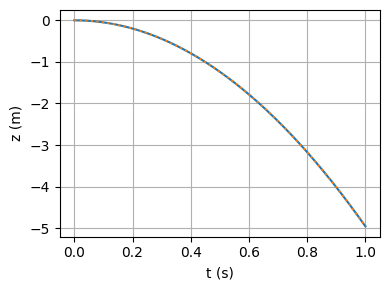

In [6]:
# -- imports
# atomsmltr
from atomsmltr.environment import ConstantForce
from atomsmltr.atoms import Ytterbium
from atomsmltr.simulation import Configuration, RK4

# other
import numpy as np
import matplotlib.pyplot as plt

# -- config
# init
config = Configuration(atom=Ytterbium())
# add force
m = Ytterbium().mass  # kg
g = 9.91  # m/s^2
grav_force = (0, 0, -m * g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")
config += gravity

# -- simulate
t = np.linspace(0, 1, 1000)
u0 = np.zeros((6,))
res = RK4(config).integrate(u0, t)
z = res.y[2, :]

# -- plot
plt.figure(figsize=(4, 3), tight_layout=True)
plt.plot(t, z)
plt.plot(t, -0.5 * g * t**2, ":")
plt.grid()
plt.xlabel("t (s)")
plt.ylabel("z (m)")
plt.show()